Router with the highest connectivity: Router3 (Degree: 10)


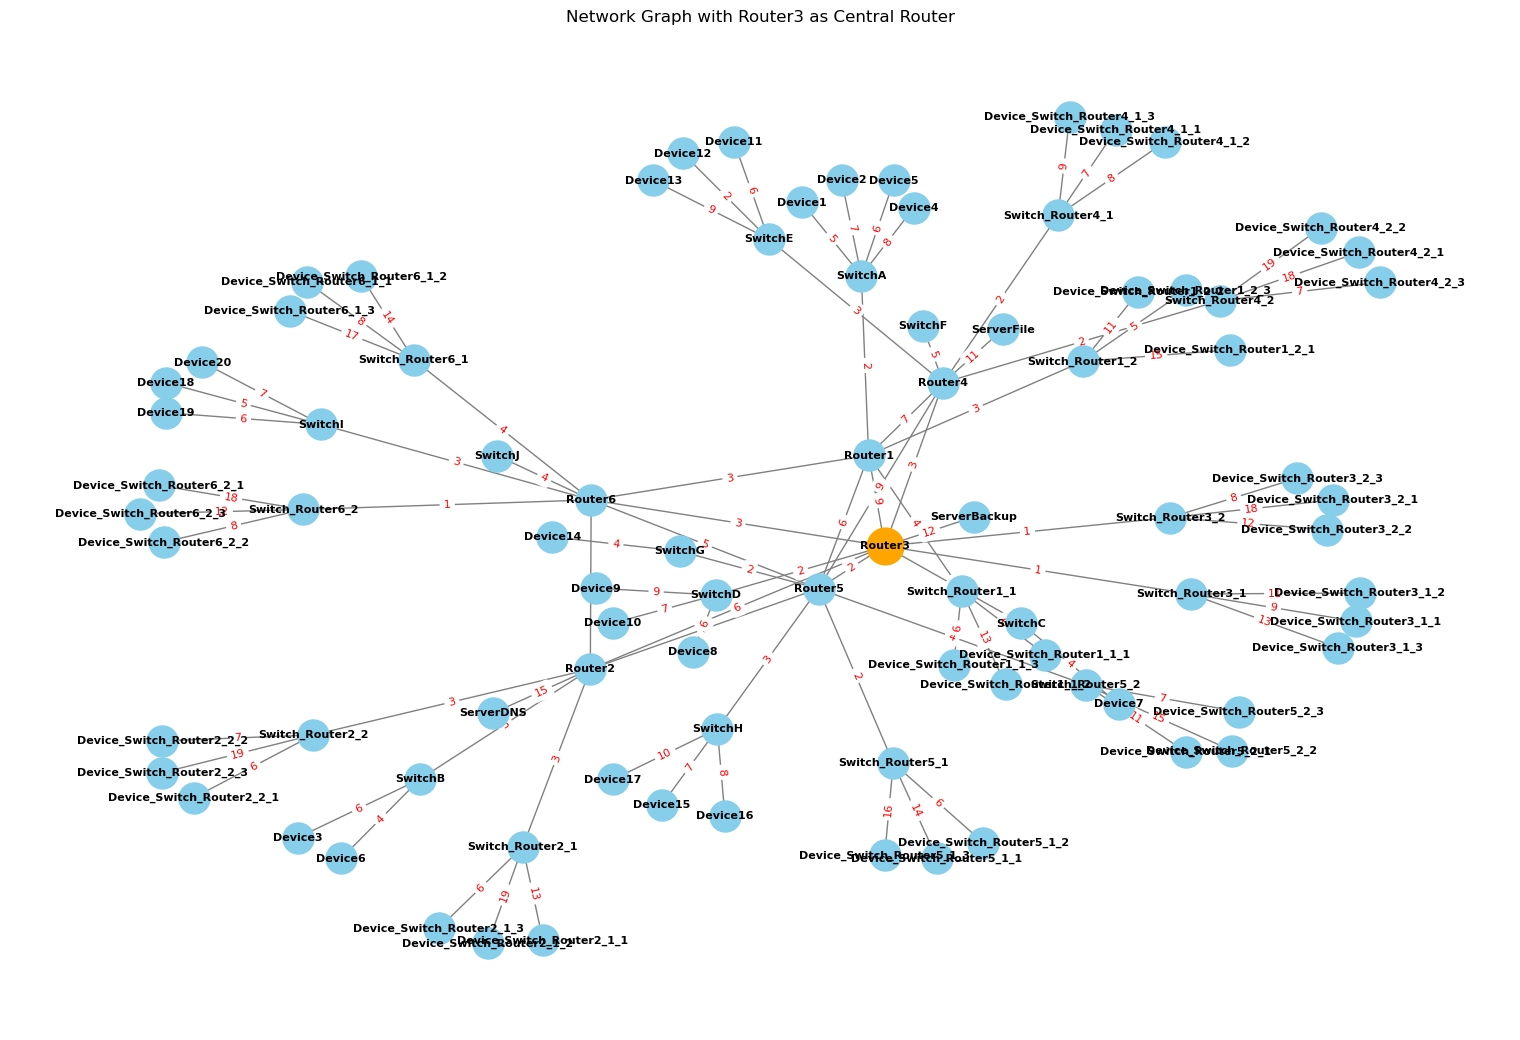

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Load the dataset
file_path = 'modified_network_graph.csv'  # Make sure this points to your local file
network_data = pd.read_csv(file_path)

# Initialize the graph
G = nx.Graph()

# Add edges with attributes
for _, row in network_data.iterrows():
    source = row['NodeID']
    target = row['ConnectedTo']
    latency = row['Latency(ms)']
    bandwidth = row['Bandwidth(Mbps)']
    
    # Add edge to the graph with latency as weight for visualization
    G.add_edge(source, target, latency=latency)

# Identify routers in the network
routers = [node for node in G.nodes if "Router" in node]

# Determine the router with the highest connectivity (degree centrality)
router_connectivity = {router: G.degree(router) for router in routers}
central_router = max(router_connectivity, key=router_connectivity.get)

print(f"Router with the highest connectivity: {central_router} (Degree: {router_connectivity[central_router]})")

# Set positions for visualization
pos = nx.spring_layout(G, seed=42)  # Adjust layout for consistent view

# Draw the graph
plt.figure(figsize=(15, 10))
nx.draw(G, pos, with_labels=True, node_size=500, node_color='skyblue', edge_color='gray', font_size=8, font_weight='bold')

# Highlight the central router in orange
nx.draw_networkx_nodes(G, pos, nodelist=[central_router], node_color='orange', node_size=700)

# Adding edge labels for latency
edge_labels = nx.get_edge_attributes(G, 'latency')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', font_size=8)

plt.title(f"Network Graph with {central_router} as Central Router")
plt.show()


In [4]:
# Locate all servers and print their respective routers
server_locations = network_data[(network_data['NodeType'] == 'Server')][['NodeID', 'ConnectedTo']]
print("Server Locations:")
for _, row in server_locations.iterrows():
    print(f"Server {row['NodeID']} is connected to {row['ConnectedTo']}")

Server Locations:
Server ServerDNS is connected to Router2
Server ServerBackup is connected to Router3
Server ServerFile is connected to Router4


In [12]:
# Add edges with latency as the weight for shortest path calculation
for _, row in network_data.iterrows():
    source = row['NodeID']
    target = row['ConnectedTo']
    latency = row['Latency(ms)']
    G.add_edge(source, target, latency=latency)

# Set main server and Router 1 identifiers
main_server = "ServerFile"
router_1 = "Router1"

# Check that both the main server and Router 1 exist in the graph
if main_server not in G.nodes or router_1 not in G.nodes:
    raise ValueError("ServerFile or Router1 not found in the network data.")

# Total devices and devices passing through Router 1
total_devices = 0
devices_through_router_1 = 0

# Iterate through each node and calculate shortest path to the main server
for node in G.nodes:
    # Skip if node is the main server itself
    if node == main_server:
        continue
    
    # Find shortest path from the current node to the main server
    try:
        path = nx.shortest_path(G, source=node, target=main_server, weight='latency')
        total_devices += 1  # Increment total devices
        
        # Check if Router 1 is in the path
        if router_1 in path:
            devices_through_router_1 += 1
    except nx.NetworkXNoPath:
        # If no path exists, skip this node
        continue

# Display the results
print(f"Total number of devices: {total_devices}")
print(f"Number of devices passing through Router 1: {devices_through_router_1}")


Total number of devices: 86
Number of devices passing through Router 1: 14


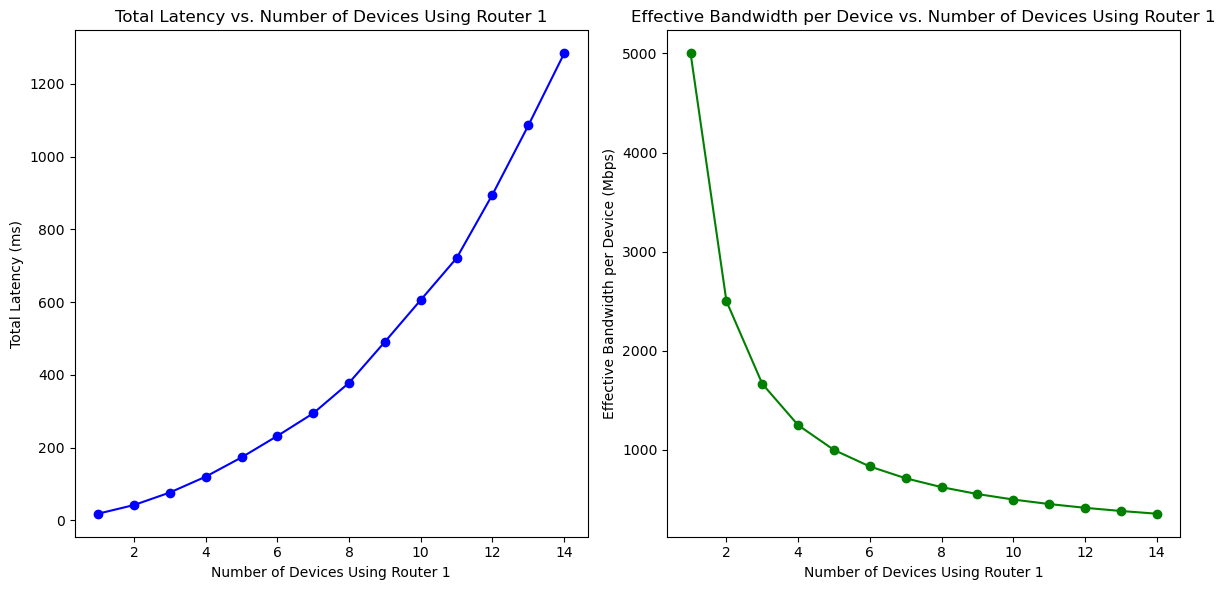

In [13]:
# Set main server and Router 1 identifiers
main_server = "ServerFile"
router_1 = "Router1"

# Check that both the main server and Router 1 exist in the graph
if main_server not in G.nodes or router_1 not in G.nodes:
    raise ValueError("ServerFile or Router1 not found in the network data.")

# Initialize lists to store results
num_devices_using_router1 = []
total_latency = []
effective_bandwidth_per_device = []

# Define a fixed total bandwidth available for Router 1
fixed_total_bandwidth = 5000  # You can adjust this based on realistic constraints

# Find paths for each device that pass through Router 1
devices_paths = []
for node in G.nodes:
    if node == main_server:
        continue
    try:
        path = nx.shortest_path(G, source=node, target=main_server, weight='latency')
        if router_1 in path:
            devices_paths.append(path)
    except nx.NetworkXNoPath:
        continue

# Simulate increasing device count using Router 1
for i in range(1, len(devices_paths) + 1):
    current_latency = 0
    
    # Calculate cumulative latency for the first 'i' devices, with an exponential effect
    for path in devices_paths[:i]:
        for j in range(len(path) - 1):
            edge_latency = G[path[j]][path[j + 1]]['latency']
            current_latency += edge_latency * (1.1 ** (i - 1))  # Apply exponential factor

    # Effective bandwidth per device
    effective_bandwidth = fixed_total_bandwidth / i

    # Store results for plotting
    num_devices_using_router1.append(i)
    total_latency.append(current_latency)
    effective_bandwidth_per_device.append(effective_bandwidth)

# Plot the latency and effective bandwidth per device as devices using Router 1 increase
plt.figure(figsize=(12, 6))

# Plot latency
plt.subplot(1, 2, 1)
plt.plot(num_devices_using_router1, total_latency, color='blue', marker='o')
plt.xlabel('Number of Devices Using Router 1')
plt.ylabel('Total Latency (ms)')
plt.title('Total Latency vs. Number of Devices Using Router 1')

# Plot effective bandwidth per device
plt.subplot(1, 2, 2)
plt.plot(num_devices_using_router1, effective_bandwidth_per_device, color='green', marker='o')
plt.xlabel('Number of Devices Using Router 1')
plt.ylabel('Effective Bandwidth per Device (Mbps)')
plt.title('Effective Bandwidth per Device vs. Number of Devices Using Router 1')

plt.tight_layout()
plt.show()


In [16]:
# Set main server and Router 4 identifiers
main_server = "ServerFile"
router_4 = "Router4"

# Check that both the main server and Router 4 exist in the graph
if main_server not in G.nodes or router_4 not in G.nodes:
    raise ValueError("ServerFile or Router4 not found in the network data.")

# Total devices and devices passing through Router 4
total_devices = 0
devices_through_router_4 = 0

# Iterate through each node and calculate shortest path to the main server
for node in G.nodes:
    # Skip if node is the main server itself
    if node == main_server:
        continue
    
    # Find shortest path from the current node to the main server
    try:
        path = nx.shortest_path(G, source=node, target=main_server, weight='latency')
        total_devices += 1  # Increment total devices
        
        # Check if Router 4 is in the path
        if router_4 in path:
            devices_through_router_4 += 1
    except nx.NetworkXNoPath:
        # If no path exists, skip this node
        continue

# Display the results
print(f"Total number of devices: {total_devices}")
print(f"Number of devices passing through Router 4: {devices_through_router_4}")


Total number of devices: 86
Number of devices passing through Router 4: 86


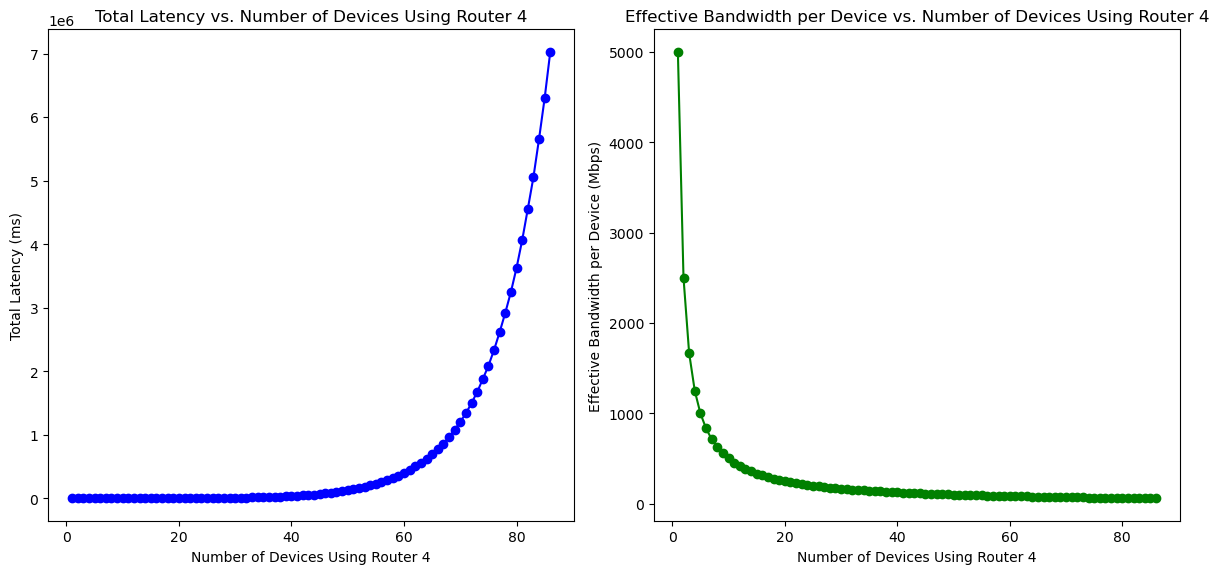

In [17]:
# Set main server and Router 4 identifiers
main_server = "ServerFile"
router_4 = "Router4"

# Check that both the main server and Router 4 exist in the graph
if main_server not in G.nodes or router_4 not in G.nodes:
    raise ValueError("ServerFile or Router4 not found in the network data.")

# Initialize lists to store results
num_devices_using_router4 = []
total_latency = []
effective_bandwidth_per_device = []

# Define a fixed total bandwidth available for Router 4
fixed_total_bandwidth = 5000  # You can adjust this based on realistic constraints

# Find paths for each device that pass through Router 4
devices_paths = []
for node in G.nodes:
    if node == main_server:
        continue
    try:
        path = nx.shortest_path(G, source=node, target=main_server, weight='latency')
        if router_4 in path:
            devices_paths.append(path)
    except nx.NetworkXNoPath:
        continue

# Simulate increasing device count using Router 4
for i in range(1, len(devices_paths) + 1):
    current_latency = 0
    
    # Calculate cumulative latency for the first 'i' devices, with an exponential effect
    for path in devices_paths[:i]:
        for j in range(len(path) - 1):
            edge_latency = G[path[j]][path[j + 1]]['latency']
            current_latency += edge_latency * (1.1 ** (i - 1))  # Apply exponential factor

    # Effective bandwidth per device
    effective_bandwidth = fixed_total_bandwidth / i

    # Store results for plotting
    num_devices_using_router4.append(i)
    total_latency.append(current_latency)
    effective_bandwidth_per_device.append(effective_bandwidth)

# Plot the latency and effective bandwidth per device as devices using Router 4 increase
plt.figure(figsize=(12, 6))

# Plot latency
plt.subplot(1, 2, 1)
plt.plot(num_devices_using_router4, total_latency, color='blue', marker='o')
plt.xlabel('Number of Devices Using Router 4')
plt.ylabel('Total Latency (ms)')
plt.title('Total Latency vs. Number of Devices Using Router 4')

# Plot effective bandwidth per device
plt.subplot(1, 2, 2)
plt.plot(num_devices_using_router4, effective_bandwidth_per_device, color='green', marker='o')
plt.xlabel('Number of Devices Using Router 4')
plt.ylabel('Effective Bandwidth per Device (Mbps)')
plt.title('Effective Bandwidth per Device vs. Number of Devices Using Router 4')

plt.tight_layout()
plt.show()


In [18]:
# Set main server and Router 3 identifiers
main_server = "ServerFile"
router_3 = "Router3"

# Check that both the main server and Router 3 exist in the graph
if main_server not in G.nodes or router_3 not in G.nodes:
    raise ValueError("ServerFile or Router3 not found in the network data.")

# Total devices and devices passing through Router 3
total_devices = 0
devices_through_router_3 = 0

# Iterate through each node and calculate shortest path to the main server
for node in G.nodes:
    # Skip if node is the main server itself
    if node == main_server:
        continue
    
    # Find shortest path from the current node to the main server
    try:
        path = nx.shortest_path(G, source=node, target=main_server, weight='latency')
        total_devices += 1  # Increment total devices
        
        # Check if Router 3 is in the path
        if router_3 in path:
            devices_through_router_3 += 1
    except nx.NetworkXNoPath:
        # If no path exists, skip this node
        continue

# Display the results
print(f"Total number of devices: {total_devices}")
print(f"Number of devices passing through Router 3: {devices_through_router_3}")


Total number of devices: 86
Number of devices passing through Router 3: 58


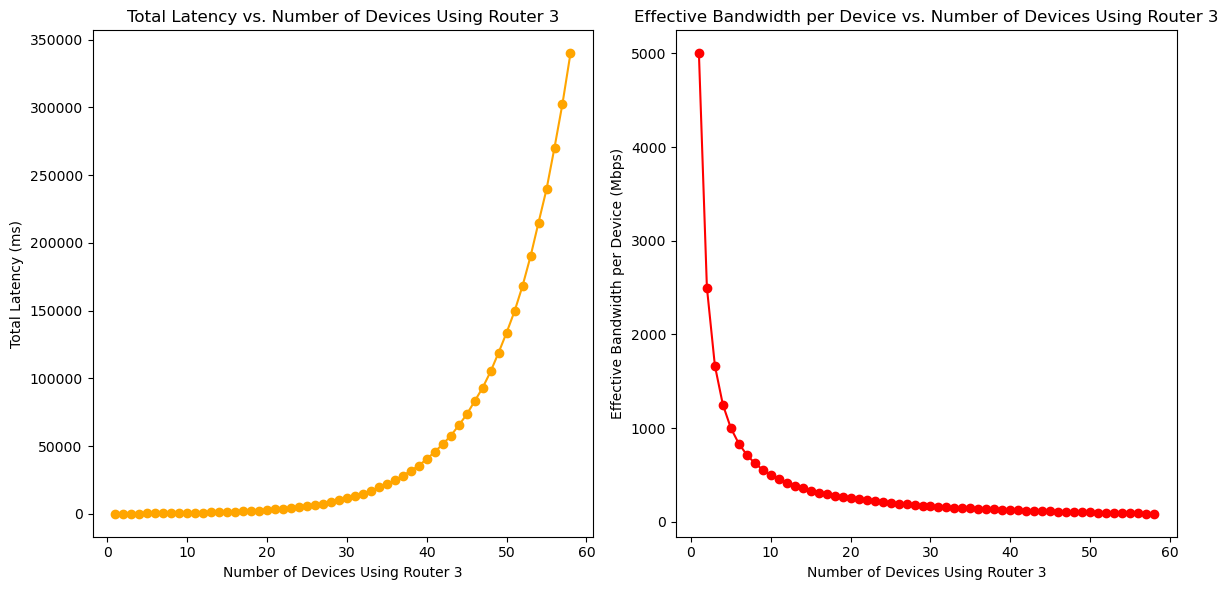

In [19]:
# Set main server and Router 3 identifiers
main_server = "ServerFile"
router_3 = "Router3"

# Check that both the main server and Router 3 exist in the graph
if main_server not in G.nodes or router_3 not in G.nodes:
    raise ValueError("ServerFile or Router3 not found in the network data.")

# Initialize lists to store results for Router 3
num_devices_using_router3 = []
total_latency_router3 = []
effective_bandwidth_per_device_router3 = []

# Define a fixed total bandwidth available for Router 3
fixed_total_bandwidth = 5000  # You can adjust this based on realistic constraints

# Find paths for each device that pass through Router 3
devices_paths = []
for node in G.nodes:
    if node == main_server:
        continue
    try:
        path = nx.shortest_path(G, source=node, target=main_server, weight='latency')
        if router_3 in path:
            devices_paths.append(path)
    except nx.NetworkXNoPath:
        continue

# Simulate increasing device count using Router 3
for i in range(1, len(devices_paths) + 1):
    current_latency = 0
    
    # Calculate cumulative latency for the first 'i' devices, with an exponential effect
    for path in devices_paths[:i]:
        for j in range(len(path) - 1):
            edge_latency = G[path[j]][path[j + 1]]['latency']
            current_latency += edge_latency * (1.1 ** (i - 1))  # Apply exponential factor

    # Effective bandwidth per device
    effective_bandwidth = fixed_total_bandwidth / i

    # Store results for plotting
    num_devices_using_router3.append(i)
    total_latency_router3.append(current_latency)
    effective_bandwidth_per_device_router3.append(effective_bandwidth)

# Plot the results for Router 3
plt.figure(figsize=(12, 6))

# Plot latency
plt.subplot(1, 2, 1)
plt.plot(num_devices_using_router3, total_latency_router3, color='orange', marker='o')
plt.xlabel('Number of Devices Using Router 3')
plt.ylabel('Total Latency (ms)')
plt.title('Total Latency vs. Number of Devices Using Router 3')

# Plot effective bandwidth per device
plt.subplot(1, 2, 2)
plt.plot(num_devices_using_router3, effective_bandwidth_per_device_router3, color='red', marker='o')
plt.xlabel('Number of Devices Using Router 3')
plt.ylabel('Effective Bandwidth per Device (Mbps)')
plt.title('Effective Bandwidth per Device vs. Number of Devices Using Router 3')

plt.tight_layout()
plt.show()


In [21]:
# Define column names based on the structure observed
columns = ["Device_Name", "Type", "IP_Address", "Data_Traffic", "Metric", "Connected_Device"]

# Add edges to the graph based on connections in the dataset
for _, row in data.iterrows():
    device1 = row['Device_Name']
    device2 = row['Connected_Device']
    G.add_edge(device1, device2)

# Define a function to count paths that pass through each router
def count_paths_through_routers(graph, routers):
    path_counts = {router: 0 for router in routers}  # Initialize counts for each router

    # Iterate over all pairs of devices in the graph
    devices = list(graph.nodes)
    for i, source in enumerate(devices):
        for target in devices[i + 1:]:  # Avoid redundant pairs and self-pairs
            # Find all paths between source and target
            all_paths = list(nx.all_simple_paths(graph, source=source, target=target))
            for path in all_paths:
                # Check if each router is in the path (excluding endpoints)
                for router in routers:
                    if router in path[1:-1]:  # Exclude start and end points
                        path_counts[router] += 1  # Increment count if the router is in the path

    return path_counts

# List of routers to check
routers = ['Router1', 'Router2', 'Router3', 'Router4', 'Router5', 'Router6']

# Count paths passing through each router
path_counts = count_paths_through_routers(G, routers)

# Display the results
print("Number of paths passing through each router:")
for router, count in path_counts.items():
    print(f"{router}: {count}")


Number of paths passing through each router:
Router1: 56744
Router2: 47632
Router3: 62849
Router4: 49138
Router5: 62594
Router6: 56754


Number of paths passing through each router:
Router1: 56744
Router2: 47632
Router3: 62849
Router4: 49138
Router5: 62594
Router6: 56754


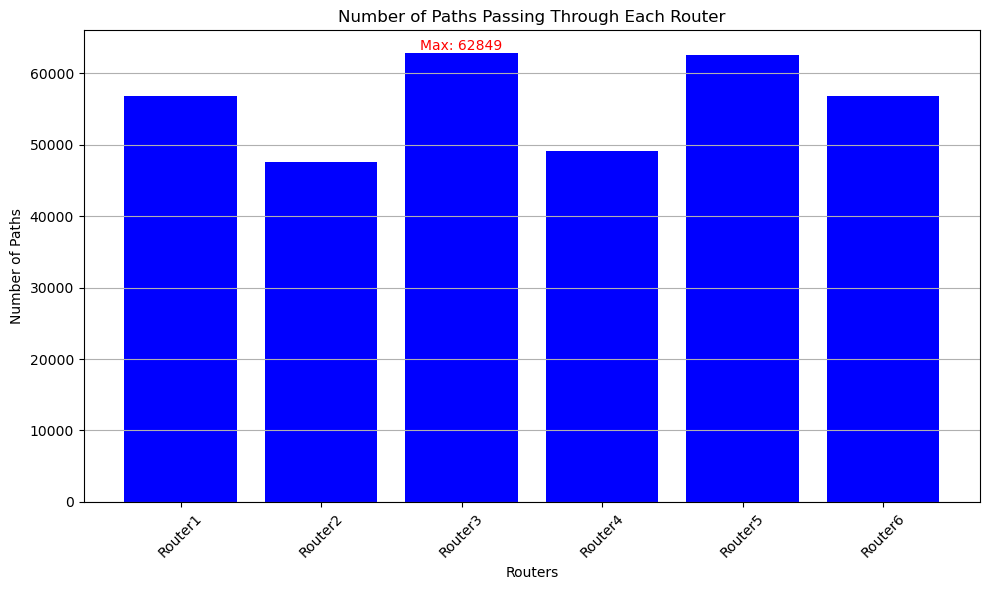

In [22]:
# Define a function to count paths that pass through each router
def count_paths_through_routers(graph, routers):
    path_counts = {router: 0 for router in routers}  # Initialize counts for each router

    # Iterate over all pairs of devices in the graph
    devices = list(graph.nodes)
    for i, source in enumerate(devices):
        for target in devices[i + 1:]:  # Avoid redundant pairs and self-pairs
            # Find all paths between source and target
            all_paths = list(nx.all_simple_paths(graph, source=source, target=target))
            for path in all_paths:
                # Check if each router is in the path (excluding endpoints)
                for router in routers:
                    if router in path[1:-1]:  # Exclude start and end points
                        path_counts[router] += 1  # Increment count if the router is in the path

    return path_counts

# List of routers to check
routers = ['Router1', 'Router2', 'Router3', 'Router4', 'Router5', 'Router6']

# Count paths passing through each router
path_counts = count_paths_through_routers(G, routers)

# Display the results
print("Number of paths passing through each router:")
for router, count in path_counts.items():
    print(f"{router}: {count}")

# Plotting the path counts for each router
plt.figure(figsize=(10, 6))
plt.bar(path_counts.keys(), path_counts.values(), color='blue')
plt.xlabel('Routers')
plt.ylabel('Number of Paths')
plt.title('Number of Paths Passing Through Each Router')
plt.xticks(rotation=45)
plt.grid(axis='y')

# Highlight the router with the maximum traffic
max_router = max(path_counts, key=path_counts.get)
max_value = path_counts[max_router]
plt.text(max_router, max_value, f'Max: {max_value}', ha='center', va='bottom', fontsize=10, color='red')

plt.tight_layout()
plt.show()


Router with the highest connectivity: Router3 (Degree: 10)


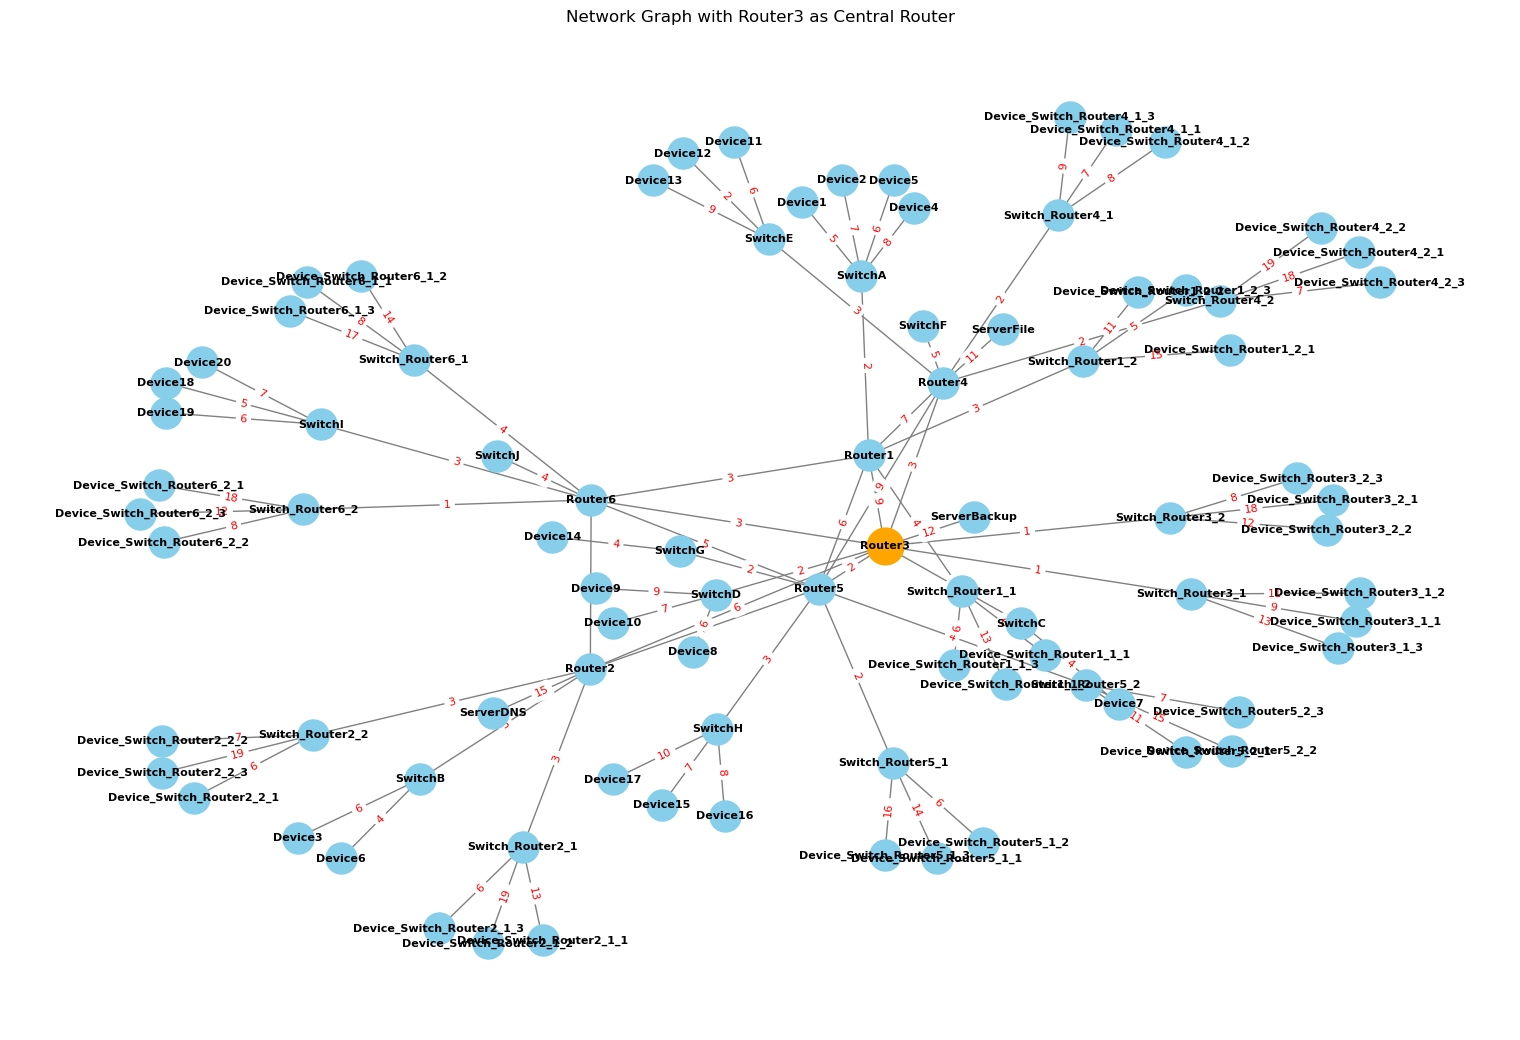

Enter the starting device:  Device1
Enter the ending device:  Device3


All possible paths with their total latency:
Path: Device1 -> SwitchA -> Router1 -> Router3 -> Router2 -> SwitchB -> Device3 | Total Latency: 31 ms
Path: Device1 -> SwitchA -> Router1 -> Router3 -> Router4 -> Router5 -> Router2 -> SwitchB -> Device3 | Total Latency: 45 ms
Path: Device1 -> SwitchA -> Router1 -> Router3 -> Router4 -> Router5 -> Router6 -> Router2 -> SwitchB -> Device3 | Total Latency: 49 ms
Path: Device1 -> SwitchA -> Router1 -> Router3 -> Router5 -> Router2 -> SwitchB -> Device3 | Total Latency: 35 ms
Path: Device1 -> SwitchA -> Router1 -> Router3 -> Router5 -> Router6 -> Router2 -> SwitchB -> Device3 | Total Latency: 39 ms
Path: Device1 -> SwitchA -> Router1 -> Router3 -> Router6 -> Router2 -> SwitchB -> Device3 | Total Latency: 35 ms
Path: Device1 -> SwitchA -> Router1 -> Router3 -> Router6 -> Router5 -> Router2 -> SwitchB -> Device3 | Total Latency: 41 ms
Path: Device1 -> SwitchA -> Router1 -> Router4 -> Router3 -> Router2 -> SwitchB -> Device3 | Total Latency: 32 ms

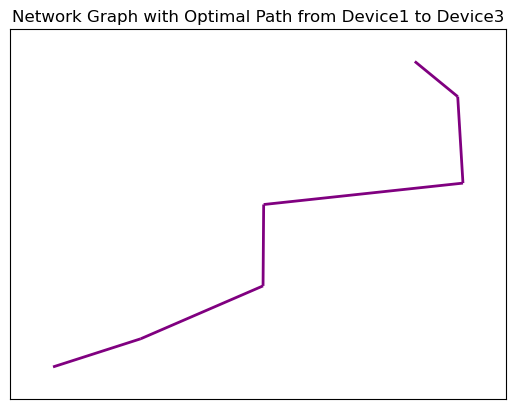

In [26]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Load the dataset
file_path = 'modified_network_graph.csv'  # Make sure this points to your local file
network_data = pd.read_csv(file_path)

# Initialize the graph
G = nx.Graph()

# Add edges with attributes
for _, row in network_data.iterrows():
    source = row['NodeID']
    target = row['ConnectedTo']
    latency = row['Latency(ms)']
    bandwidth = row['Bandwidth(Mbps)']
    
    # Add edge to the graph with latency as weight for visualization
    G.add_edge(source, target, latency=latency, bandwidth=bandwidth)

# Recursive function to find all paths using DFS
def dfs_all_paths(graph, start, end, path=[], total_latency=0):
    path = path + [start]
    if start == end:
        return [(path, total_latency)]
    
    all_paths = []
    for neighbor in graph[start]:
        if neighbor not in path:  # Avoid cycles
            edge_latency = graph[start][neighbor]['latency']
            all_paths.extend(dfs_all_paths(graph, neighbor, end, path, total_latency + edge_latency))
    
    return all_paths

# Identify routers in the network
routers = [node for node in G.nodes if "Router" in node]

# Determine the router with the highest connectivity (degree centrality)
router_connectivity = {router: G.degree(router) for router in routers}
central_router = max(router_connectivity, key=router_connectivity.get)

print(f"Router with the highest connectivity: {central_router} (Degree: {router_connectivity[central_router]})")

# Set positions for visualization
pos = nx.spring_layout(G, seed=42)  # Adjust layout for consistent view

# Draw the graph
plt.figure(figsize=(15, 10))
nx.draw(G, pos, with_labels=True, node_size=500, node_color='skyblue', edge_color='gray', font_size=8, font_weight='bold')

# Highlight the central router in orange
nx.draw_networkx_nodes(G, pos, nodelist=[central_router], node_color='orange', node_size=700)

# Adding edge labels for latency
edge_labels = nx.get_edge_attributes(G, 'latency')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', font_size=8)

plt.title(f"Network Graph with {central_router} as Central Router")
plt.show()

# Main function to handle user input for pathfinding
def main():
    start_device = input("Enter the starting device: ").strip()  # User input for starting device
    end_device = input("Enter the ending device: ").strip()      # User input for ending device

    if start_device not in G or end_device not in G:
        print("One or both of the devices are not in the network.")
        return

    all_paths = dfs_all_paths(G, start_device, end_device)

    if not all_paths:
        print(f"There is no path between {start_device} and {end_device}.")
    else:
        # Display all paths and their latencies
        print("All possible paths with their total latency:")
        for path, latency in all_paths:
            print(f"Path: {' -> '.join(path)} | Total Latency: {latency} ms")

        # Get the path with minimum latency
        optimal_path, min_latency = min(all_paths, key=lambda x: x[1])
        print(f"\nThe shortest path from {start_device} to {end_device} is: {' -> '.join(optimal_path)}")
        print(f"The total latency for this path is: {min_latency} ms")

        # Highlight the optimal path in the graph
        path_edges = [(optimal_path[i], optimal_path[i + 1]) for i in range(len(optimal_path) - 1)]
        nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='purple', width=2)

        plt.title(f"Network Graph with Optimal Path from {start_device} to {end_device}")
        plt.show()

# Run the main function
if __name__ == "__main__":
    main()